In [7]:
print("all ok")

all ok


In [ ]:
graph()
state
edges
nodes
invoke
stategraph()



In [9]:
def function1(input1):
    return input1+ " from first function"

In [10]:
def function2(input2):
    return input2+ " savita from second function"

In [11]:
def function3(input3):
    pass

In [12]:
function1("sunny")

'sunny from first function'

In [13]:
function2("savita")

'savita savita from second function'

In [37]:
# from langgraph.graph import Graph
from langgraph.graph import StateGraph

In [43]:
workflow1=Graph()

In [44]:
workflow1.add_node("fun1",function1)

In [45]:
workflow1.add_node("fun2",function2)

In [46]:
workflow1.add_edge("fun1","fun2")

In [47]:
workflow1.set_entry_point("fun1")

In [48]:
workflow1.set_finish_point("fun2")

In [49]:
app=workflow1.compile()

In [50]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun1': Node(id='fun1', name='fun1', data=fun1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'fun2': Node(id='fun2', name='fun2', data=fun2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='fun1', data=None, conditional=False), Edge(source='fun1', target='fun2', data=None, conditional=False), Edge(source='fun2', target='__end__', data=None, conditional=False)])

In [51]:
from IPython.display import Image, display

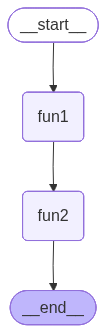

In [52]:
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
app.invoke("hi this is sunny")

'hi this is sunny from first function savita from second function'

In [53]:
for output in app.stream("hi this is rohit"):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")
    

here is output from fun1
_______
hi this is rohit from first function


here is output from fun2
_______
hi this is rohit from first function savita from second function




In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
model=ChatGoogleGenerativeAI(model='gemini-flash-lite-latest')

In [2]:
# helper: list available Gemini models for this API key
try:
    models = []
    for m in model.client.models.list():
        model_name = getattr(m, "name", "")
        if "gemini" in model_name.lower():
            models.append(model_name)
    print("Available Gemini models:")
    for name in models[:30]:
        print(name)
except Exception as e:
    print("Could not list models:", e)

Available Gemini models:
models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3-pro-image-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/gemini-embedding-001
models/gemini-2.5-flash-native-audio-latest
models/gemini-2.5-flash-native-audio-preview-09-2025
models/gemini-2.5-flash-native-audio-preview-12-2025


In [62]:
model.invoke("hi").content

'Hi there! How can I help you today?'

In [64]:
def llm(input):
    from langchain_google_genai import ChatGoogleGenerativeAI
    model=ChatGoogleGenerativeAI(model='gemini-flash-lite-latest')
    output=model.invoke(input)
    return output.content

In [65]:
def token_counter(input):
    token=input.split()
    token_number=len(token)
    return f"total token number in the generated answer is {token_number}"

In [66]:
workflow2=Graph()

In [67]:
workflow2.add_node("My_LLM",llm)

In [68]:
workflow2.add_node("LLM_Output_Token_Counter",token_counter)

In [69]:
workflow2.add_edge("My_LLM","LLM_Output_Token_Counter")

In [70]:
workflow2.set_entry_point("My_LLM")

In [71]:
workflow2.set_finish_point("LLM_Output_Token_Counter")

In [72]:
app=workflow2.compile()

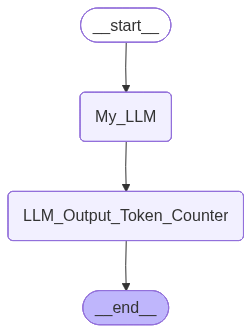

In [73]:
display(Image(app.get_graph().draw_mermaid_png()))

In [74]:
app.invoke("can you tell me about the india's capital?")

'total token number in the generated answer is 616'

In [75]:
app.invoke("tell me about the tata enterpirse in very detail.")

'total token number in the generated answer is 1244'

In [76]:
for output in app.stream("tell me about the tata enterpirse in very detail."):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from My_LLM
_______
The Tata Group is one of India's oldest, largest, and most respected conglomerates. It is a global powerhouse with a presence across numerous sectors, known for its commitment to ethical business practices, nation-building, and social responsibility.

Here is a detailed overview of the Tata Enterprise:

---

## 1. Overview and History

The Tata Group was founded in **1868** by **Jamsetji Nusserwanji Tata**. It began as a trading firm and has since evolved into a multinational conglomerate operating in over 100 countries.

**Founding Philosophy:** Jamsetji Tata's vision was rooted in industrializing India and ensuring that the wealth generated benefited the nation and its people. This philosophy is encapsulated in the group’s core ethos: **"What advances the interests of the community, advances the interests of the business."**

**Structure:** The Tata Group is not a single company but a collection of over **100 Tata companies** spread across diverse i